<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/Spectral_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####**B.5. Implement the spectral clustering algorithm and test its performance on the spiral dataset. Compare these clustering results with those obtained by the simple K-means clustering algorithm.**

**Spectral Clustering**

Spectral clustering is a graph-based unsupervised clustering method that uses eigenvalues and eigenvectors of the graph Laplacian to detect clusters, especially non-convex ones.



**Similarity Matrix**

Given data points
$
\{x_1, x_2, \ldots, x_n\},
$
the similarity matrix $\( W \in \mathbb{R}^{n \times n} \)& is defined as

$
W_{ij} = \exp\left( -\frac{\lVert x_i - x_j \rVert^2}{2\sigma^2} \right),
$

or more generally,

$
W_{ij} = k(x_i, x_j),
$

where $( \lVert x_i - x_j \rVert )$ denotes the Euclidean distance between data points $( x_i ) and ( x_j )$,  
$( \sigma > 0 )$ is a scaling parameter, and  
$( k(\cdot, \cdot) )$ is  a kernel (similarity) function.


**Degree Matrix**

$
D_{ii} = \sum_{j=1}^{n} W_{ij},
$



**Graph Laplacian**

Unnormalized Laplacian:
$
L = D - W
$

Normalized Laplacian (commonly used):
$
L_{\mathrm{sym}} = D^{-1/2} L D^{-1/2}
$

Substituting \( L = D - W \),
$
L_{\mathrm{sym}} = D^{-1/2} (D - W) D^{-1/2}
= I - D^{-1/2} W D^{-1/2}.
$


**Eigen Decomposition**

Compute the first \( k \) eigenvectors of the normalized graph Laplacian:

$
L_{\mathrm{sym}} \, u_i = \lambda_i \, u_i,
\qquad i = 1, \ldots, k.
$

Form the matrix:

$
U = \left[ u_1, u_2, \ldots, u_k \right] \in \mathbb{R}^{n \times k}.
$
``


Row Normalization

Each row of \( U \) is normalized to unit length to obtain matrix \( Y \):

$
Y_{ij} = \frac{U_{ij}}{\sqrt{\sum_{j=1}^{k} U_{ij}^{2}}}
$


**Why Spectral Clustering Works**

Spectral clustering approximately minimizes graph partitioning objectives defined on the similarity graph.


$
\mathrm{RatioCut}(C_1, \ldots, C_k)
= \sum_{i=1}^{k}
\frac{\mathrm{cut}(C_i, \overline{C}_i)}{|C_i|},
$

Normalized Cut:

$\text{Ncut}(C_1, \ldots, C_k)
=
\sum_{i=1}^{k}
\frac{\text{cut}(C_i, \bar{C}_i)}{\text{vol}(C_i)}.
$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def make_spiral(n_points=300, noise=0.5):
    n = n_points // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi

    r_a = 2 * theta + np.pi
    data_a = np.array([
        r_a * np.cos(theta),
        r_a * np.sin(theta)
    ]).T

    r_b = -2 * theta - np.pi
    data_b = np.array([
        r_b * np.cos(theta),
        r_b * np.sin(theta)
    ]).T

    X = np.vstack([data_a, data_b])
    X += noise * np.random.randn(*X.shape)
    return X

In [ ]:
X = make_spiral(300)

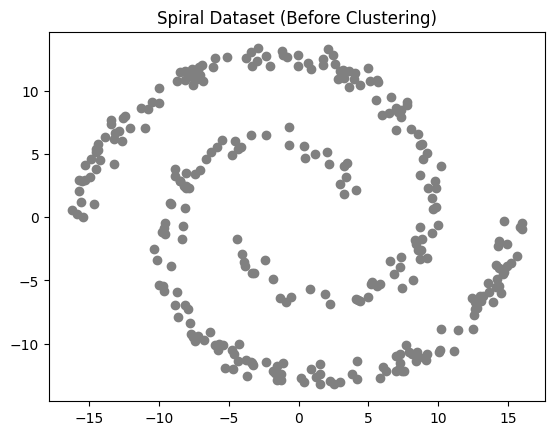

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c='gray')
plt.title("Spiral Dataset (Before Clustering)")
plt.show()

In [ ]:
def affinity_matrix(X, sigma=1.0):
    n = len(X)
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist = np.linalg.norm(X[i] - X[j])
            W[i, j] = np.exp(-(dist ** 2) / (2 * sigma ** 2))
    return W

In [ ]:
def laplacian_matrix(W):
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    return L

In [ ]:
class KMeans:
    def __init__(self, k=2, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        self.centroids = X[np.random.choice(len(X), self.k, replace=False)]

        for _ in range(self.max_iters):
            clusters = [[] for _ in range(self.k)]

            for point in X:
                distances = [
                    np.linalg.norm(point - centroid)
                    for centroid in self.centroids
                ]
                idx = np.argmin(distances)
                clusters[idx].append(point)

            new_centroids = [
                np.mean(cluster, axis=0)
                for cluster in clusters
            ]

            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

    def predict(self, X):
        labels = []
        for point in X:
            distances = [
                np.linalg.norm(point - centroid)
                for centroid in self.centroids
            ]
            labels.append(np.argmin(distances))
        return np.array(labels)

In [ ]:
def spectral_clustering(X, k=2, sigma=1.0):
    # 1. Similarity graph
    W = affinity_matrix(X, sigma)

    # 2. Laplacian
    L = laplacian_matrix(W)

    # 3. Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    # 4. Select k smallest eigenvectors
    U = eigenvectors[:, :k]

    # 5. K-means on spectral embedding
    kmeans = KMeans(k)
    kmeans.fit(U)
    labels = kmeans.predict(U)

    return labels

In [ ]:
spectral_labels = spectral_clustering(X, k=2, sigma=1.0)

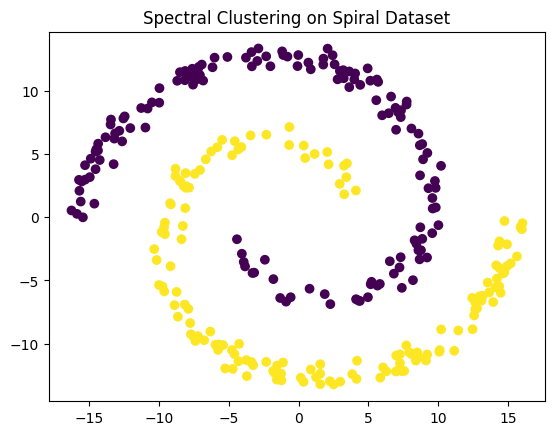

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='viridis')
plt.title("Spectral Clustering on Spiral Dataset")
plt.show()
